In [1]:
from itertools import product
import logging
import os
import pickle
import sys

import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import stats
from scipy.spatial import Delaunay, delaunay_plot_2d

from eryn.ensemble import EnsembleSampler
from eryn.moves import DistributionGenerateRJ, StretchMove, GaussianMove
from eryn.prior import uniform_dist, ProbDistContainer
from eryn.state import State

import corner
from tqdm import trange

from local_utils import delaunaytor
from local_utils.moves import BinGaussRelMove

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
plt.style.use("tableau-colorblind10")

In [2]:
def chi_log_prior(chi, mu_chi, var_chi):
    nu = mu_chi * (1 - mu_chi) / var_chi - 1.

    alpha_chi = mu_chi * nu
    beta_chi = (1 - mu_chi) * nu

    zero_mask = np.logical_or(nu < 0, np.logical_or(alpha_chi < 0, beta_chi < 0))
    
    return np.where(
        zero_mask, 
        -1e300, 
        stats.beta(a=alpha_chi, b=beta_chi).logpdf(chi)
    )

def tilts_log_prior(tilt_1, tilt_2, zeta, sigma_t):
    truncated_gaussian = stats.truncnorm(
        loc=0, scale=sigma_t, a=-1/sigma_t, b=1/sigma_t
    )
    
    gauss_prod = truncated_gaussian.pdf(tilt_1) * truncated_gaussian.pdf(tilt_2)
    return np.where(
        gauss_prod <= 0.,
        -1e300,
        np.log(0.25 * (1 - zeta) + zeta * gauss_prod)
    )

In [4]:
# READ data and injections
parameter_keys = ["m1", "z", "q", "chi1", "chi2", "tilt1", "tilt2"]
total_dimensions = len(parameter_keys)

data_file = np.load("./lvc_data_lvc_samples_full.npz")
observed_events = np.vstack([data_file[key + "s"] for key in parameter_keys]).T
event_logpriors = data_file["priors"]
num_events = data_file["nevents"][0]
num_samples = data_file["nsamples"][0]

per_event_arrange = observed_events.reshape(num_events, num_samples, observed_events.shape[-1]) 
kill_these = (per_event_arrange[:, :, 0] > 100)
#event_logpriors[kill_these] = 1e300
#observed_events = per_event_arrange[~kill_these].reshape(-1, 7)
#event_logpriors = event_logpriors.reshape(num_events, num_samples, 1)[~kill_these].reshape(-1, )
#num_events = (~kill_these).sum()

event_barycenters = observed_events.reshape(
    (num_events, num_samples, observed_events.shape[-1])
).mean(axis=1)

injections_file = np.load("./selection_function_elements.npz")
detected_injections = np.vstack(
    [injections_file[key + "s"] for key in parameter_keys]
).T
injection_priors = injections_file["inj_priors"]
num_injections = injections_file["ninjs"]

In [5]:
class SimpleDelaunay(delaunaytor.DelaunayLogLikelihood):

    def rate(self, triangulation_params):
        self.delaunay_interpolator.triangulate(triangulation_params)

        events_simplex, events_b = self.delaunay_interpolator.simplex_and_barycenters(
            self.events
        )

        samples_inside = (events_simplex != -1).reshape(
            self.num_events, self.num_samples
        )

        log_dNdtheta_samples = self.delaunay_interpolator._interpolate(
            events_simplex, events_b
        )

        inj_simplex, inj_b = self.delaunay_interpolator.simplex_and_barycenters(
            self.detected_injections
        )
        log_Nxi = self.delaunay_interpolator._interpolate(inj_simplex, inj_b)

        maybe_infinity = np.exp(log_Nxi)
        if np.isinf(maybe_infinity).any():
            return self.minus_infinity

        inj_inside = inj_simplex != -1

        return (
            log_dNdtheta_samples,
            samples_inside,
            maybe_infinity,
            inj_inside,
        )


In [6]:
class M1ZQDelaunay:
    
    def __init__(
        self,
        events,
        events_log_prior,
        num_events,
        num_samples,
        detected_injections,
        detected_injections_prior,
        num_injections,
        corners,
        minus_infinity=-1e300,
    ):
        delaunay_indices = (0, 1, 2)
        if len(delaunay_indices) != 3:
            raise ValueError("Three is the number of dimensions I shall triangulate over")

        self.delaunay_rate = SimpleDelaunay(
            events=events[:, delaunay_indices],
            events_log_prior=event_logpriors,
            num_events=num_events,
            num_samples=num_samples,
            detected_injections=detected_injections[:, delaunay_indices],
            detected_injections_prior=detected_injections_prior,
            num_injections=num_injections,
            minus_infinity=None,
        )

            
        self.corners = corners

        self.events = events
        self.num_events = num_events
        self.num_samples = num_samples
        self.log_num_samples = np.log(num_samples)

        self.events_log_prior = events_log_prior.reshape(
            self.num_events, self.num_samples
        )

        self.detected_injections = detected_injections
        self.detected_injections_prior = detected_injections_prior
        self.num_injections = num_injections

        self.minus_infinity = minus_infinity
            
    def __call__(self, population_parameters):
        (inner_tri_parameters, corner_weights, mu_var_chi, zeta_sigma_t) = population_parameters
        
        mu_var_chi = mu_var_chi.squeeze()
        zeta_sigma_t = zeta_sigma_t.squeeze()
                
        triangulation_parameters = np.vstack([
            inner_tri_parameters,
            np.c_[self.corners, corner_weights.T]
        ])
        
        if (tri_result := self.delaunay_rate.rate(triangulation_parameters)) is None:
            return self.minus_infinity
        (
            log_dNdtheta_tri,
            samples_inside_tri,
            Nxi_tri,
            inj_inside_tri,
        ) = tri_result
                
        # parameter_keys = ["m1", "z", "q", "chi1", "chi2", "tilt1", "tilt2"]
        log_dNdtheta = (
            log_dNdtheta_tri
            + chi_log_prior(self.events[:, 3], mu_var_chi[0], mu_var_chi[1])
            + chi_log_prior(self.events[:, 4], mu_var_chi[0], mu_var_chi[1])
            + tilts_log_prior(self.events[:, 5], self.events[:, 6], zeta_sigma_t[0], zeta_sigma_t[1])
        ).reshape(self.num_events, self.num_samples)
                
        to_integrate = log_dNdtheta - self.events_log_prior
        log_bayes_factors = self.delaunay_rate.logsumexp(
            to_integrate,  b=samples_inside_tri, axis=-1
        )
        
        log_variance_likes = self.delaunay_rate.logsumexp(
            2 * to_integrate, b=samples_inside_tri, axis=-1
        )
        if np.isnan(log_variance_likes).any():
            logger.debug("Variances are bad")
            return self.minus_infinity        

        log_effective_sample_sizes = 2 * log_bayes_factors - log_variance_likes
        if ((log_effective_sample_sizes < np.log(self.num_events))).any():
            logger.debug(f"Effective sample size is too low")
            return self.minus_infinity

        
        Nxi_presum = Nxi_tri * np.exp(  
            (chi_log_prior(self.detected_injections[:, 3], mu_var_chi[0], mu_var_chi[1]))
            + chi_log_prior(self.detected_injections[:, 4], mu_var_chi[0], mu_var_chi[1])
            + tilts_log_prior(
                self.detected_injections[:, 5], 
                self.detected_injections[:, 6], 
                zeta_sigma_t[0], 
                zeta_sigma_t[1],
            )
        )
               
        Nxi = (
            integrand := (Nxi_presum * inj_inside_tri / self.detected_injections_prior)
        ).sum() / self.num_injections
        
        
        var = (
            (integrand / self.num_injections) ** 2
        ).sum() - Nxi**2 / self.num_injections
        
        n_eff = Nxi**2 / var
        if n_eff <= 4 * self.num_events:
            logger.debug("Not enough injection stuff")
            return self.minus_infinity
        
        #actual_log_num_samples = np.log(samples_inside_tri.sum(axis=1))
        actual_log_num_samples = self.log_num_samples
        
        result = (log_bayes_factors - actual_log_num_samples).sum() - Nxi
        return result.item()


In [7]:
def make_valid_delaunay(event_points, injection_points, num_vertices, corners):
    
    points = np.vstack([
        event_points, 
    ])

    dim = event_points.shape[1]
    num_corners = 2**dim
    
    min_max_dim = np.vstack([
        [np.min(points[:, d]), np.max(points[:, d])] for d in range(dim)
    ])
    
    vertices = np.zeros((num_vertices + num_corners, dim))
    valid_vertices = 0
    vertices[:corners.shape[0]] = corners

    c = 0
    for _ in range(10_000):
        vertices[valid_vertices + num_corners] = np.random.uniform(
            low=min_max_dim[:, 0], high=min_max_dim[:, 1]
        )
        
        this_tri = Delaunay(vertices[: num_corners + 1 + valid_vertices])
        points_simplex = this_tri.find_simplex(points)
        event_simplex = points_simplex[: event_points.shape[0]]

        no_empty = True #np.isin(np.arange(this_tri.nsimplex), event_simplex).all()
        no_points_outside = (points_simplex != -1).all()
        if no_empty and no_points_outside:
            valid_vertices += 1
        
        if valid_vertices >= num_vertices:
            break
    else:
        raise ValueError("Triangulation didn't work!")


    return vertices[num_corners:]

In [8]:
z_min = 1e-6
z_max = 2.3
m1_min = 2. 
m1_max = 101. + 1e-6
q_min = 0.
q_max = 1.

corners = np.array([
        [m1_min, z_min, q_min],
        [m1_min, z_min, q_max],
        [m1_min, z_max, q_min],
        [m1_min, z_max, q_max],
        [m1_max, z_min, q_min],
        [m1_max, z_min, q_max],
        [m1_max, z_max, q_min],
        [m1_max, z_max, q_max],
    ])

log_like_fn = M1ZQDelaunay(
    events=observed_events,
    events_log_prior=event_logpriors,
    num_events=num_events,
    num_samples=num_samples,
    detected_injections=detected_injections,
    detected_injections_prior=injection_priors,
    num_injections=num_injections,
    corners=corners,
)

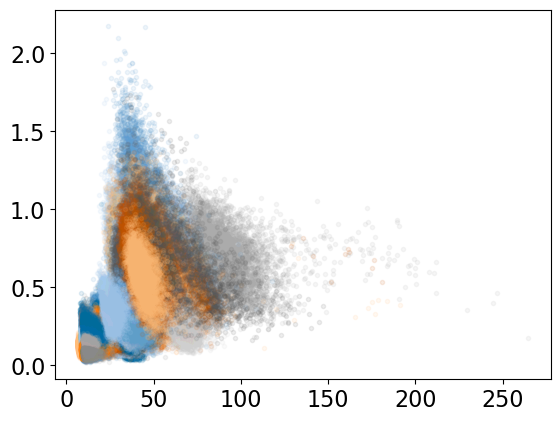

In [10]:
valid_tri = make_valid_delaunay(
    event_barycenters[:, :3],
    detected_injections[:, :3], 
    6,
    log_like_fn.corners
)

fig, ax = plt.subplots()
ax.set(xscale="linear", yscale="linear")
vertices = np.vstack([
        valid_tri,
        log_like_fn.corners,
    ])

# ax.plot(
#     vertices[:, 0], 
#     vertices[:, 1],  
#     color="black"
# )


for event_indx in range(event_barycenters.shape[0]):
    l = ax.plot(
        observed_events[event_indx * num_samples : (event_indx + 1) * num_samples, 0], 
        observed_events[event_indx * num_samples : (event_indx + 1) * num_samples, 1],
        ".",
        alpha=0.1,
        zorder=0,
    )
plt.show()
plt.close()


In [ ]:
no_plot = False

nwalkers = 4
ntemps = 2

branch_names = ["tri", "corner_w", "chi", "tilt"]
ndims = dict(zip(branch_names, [4, 8, 2, 2]))
nleaves_min = dict(zip(branch_names, [4, 1, 1, 1]))
nleaves_max = dict(zip(branch_names, [20, 1, 1, 1]))

start_with_this_many = 6

priors = {
    "tri": {
        0: uniform_dist(m1_min, m1_max), 
        1: uniform_dist(z_min, z_max), 
        2: uniform_dist(q_min, q_max),
        3: uniform_dist(-5, 15),
    },
    "corner_w": {
        i: uniform_dist(-5, 15) for i in range(ndims["corner_w"])
    },
    "chi": {
        0: uniform_dist(0, 0.95),
        1: uniform_dist(0.005, 0.25)
    },
    "tilt": {
        0: uniform_dist(0, 1),
        1: uniform_dist(0.1, 4)
    }
}


coords = {}
inds = {}

for branch in branch_names:
    coords[branch] = np.zeros((ntemps, nwalkers, nleaves_max[branch], ndims[branch])) 
    inds[branch] = np.zeros((ntemps, nwalkers, nleaves_max[branch]), dtype=bool)
    
    for i in range(ndims[branch]):
        coords[branch][..., i] = priors[branch][i].rvs(size=(ntemps, nwalkers, nleaves_max[branch]))
        
    if branch == "tri":
        inds["tri"][:, :, :start_with_this_many] = True
    else:
        inds[branch][:, :, :] = True


for t, w in product(range(ntemps), range(nwalkers)):
        
    le_log = -np.inf
    for _ in trange(10_000):
        init_proposal = {
            "tri": np.c_[
            make_valid_delaunay(
                event_barycenters[:, :3],
                detected_injections[:, :3], 
                start_with_this_many,
                log_like_fn.corners
            ),  
            priors["tri"][3].rvs(size=start_with_this_many)
        ]
        } | {
            branch: np.array(
                [priors[branch][dim_indx].rvs() for dim_indx in range(ndims[branch])]
            ).squeeze()
            for branch in priors if branch != "tri"
        }
        
        le_log = log_like_fn([
            init_proposal[key] for key in ["tri", "corner_w", "chi", "tilt"]
        ]) or -1e300

        if le_log > -1e300:
            break
    else:
        raise ValueError("Didn't work")

    print(t, w, le_log)
    for branch in init_proposal:
        coords[branch][
            t, w, : (start_with_this_many if branch == "tri" else nleaves_max[branch])
        ] = init_proposal[branch]
                

    print(le_log)

In [ ]:
for ind in trange(nwalkers):
    if no_plot:
        break
    params = np.vstack([
        coords["tri"][0, ind, inds["tri"][0, ind], :-1],
        log_like_fn.corners
    ])

    
    
    fig, ax = plt.subplots()
    ax.set_rasterized(True)

    ax.plot(
        params[:, 0], params[:, 1], "o", color="black",
    )
    
    for event_indx in range(event_barycenters.shape[0]):

        l = ax.plot(
            observed_events[event_indx * num_samples : (event_indx + 1) * num_samples, 0], 
            observed_events[event_indx * num_samples : (event_indx + 1) * num_samples, 1],
            ".",
            alpha=0.,
        )
        ax.plot(
            event_barycenters[event_indx, 0], 
            event_barycenters[event_indx, 1], 
            "*", color="white", markerfacecolor=l[0].get_color(), markersize=20, zorder=0
        )

    plt.show()
    plt.close()

In [ ]:
import numpy as np

from eryn.moves import MHMove


class BinGaussRelMove(MHMove):

    def __init__(
        self, sigma_vertices, weights_scale, ind_leaf, branch_name, *args, **kwargs
    ):

        self.sigma_vertices = sigma_vertices
        self.weights_scale = weights_scale
        self.branch_name = branch_name
        self.ind_leaf = ind_leaf

        super().__init__(*args, **kwargs)

    def get_proposal(self, branches_coords, random, branches_inds, **kwargs):

        coords = branches_coords[self.branch_name]
        inds = branches_inds[self.branch_name]

        ntemps, nwalkers, nleaves_max, ndim = coords.shape

        # replace is always true
        false_mask = ~inds[:, :, self.ind_leaf]
        random_indices = np.full((ntemps, nwalkers), -1, dtype=int)

        valid_mask = inds.any(axis=2)
        random_choice = inds * np.random.rand(ntemps, nwalkers, nleaves_max)
        random_selected = np.argmax(random_choice, axis=-1)
        random_indices[valid_mask] = random_selected[valid_mask]

        result_indices = np.where(false_mask, random_indices, self.ind_leaf)

        inds_leaf = np.take_along_axis(inds, result_indices[..., None], axis=2)[:, :, 0]
        coords_leaf = np.take_along_axis(
            coords, result_indices[..., None, None], axis=2
        )[:, :, 0]

        new_vertices = coords_leaf[:, :, :-1] + self.sigma_vertices * random.randn(
            ntemps, nwalkers, ndim - 1
        )

        sigma_weights = self.weights_scale
        new_weights = coords_leaf[:, :, -1] + sigma_weights * np.random.randn(
            ntemps, nwalkers
        )

        new_params = np.dstack([new_vertices, new_weights])

        proposal = {self.branch_name: np.copy(coords)}
        row_indices, col_indices = np.meshgrid(
            np.arange(ntemps), np.arange(nwalkers), indexing="ij"
        )
        proposal[self.branch_name][
            row_indices, col_indices, result_indices, :
        ] = new_params

        factors = 0.0

        return proposal, factors


In [ ]:
moves = [ 
        BinGaussRelMove(
            sigma_vertices=0.1 * np.array([m1_max - m1_min, z_max - z_min, q_max - q_min]),
            weights_scale=1.,
            ind_leaf=ind_leaf,
            branch_name="tri",
        )
    for ind_leaf in range(nleaves_max["tri"])
] 
moves += [
    StretchMove(
        gibbs_sampling_setup=["corner_w", "chi", "tilt"],
        live_dangerously=True
    )
]
moves += [
    StretchMove(
        gibbs_sampling_setup=["tilt"],
        live_dangerously=True
    )
]


prior_move = DistributionGenerateRJ(
    {key: ProbDistContainer(priors[key]) for key in priors},
    nleaves_min={key: val for key, val in nleaves_min.items()},
    nleaves_max={key: val for key, val in nleaves_max.items()},
)
rj_moves = [prior_move]


state = State(coords, inds=inds)

In [ ]:
nburn = 200
nsteps = 100

from multiprocessing import Pool

with Pool(5) as pool: 
    ensemble = EnsembleSampler(
        nwalkers,
        ndims,
        log_like_fn,
        priors,
        tempering_kwargs=dict(ntemps=ntemps),
        nbranches=len(branch_names),
        branch_names=branch_names,
        nleaves_max=nleaves_max,
        nleaves_min=nleaves_min,
        moves=moves,
        rj_moves=rj_moves,
        pool=pool,
    )
    last_sample = ensemble.run_mcmc(
        state, nsteps, burn=nburn, progress=True, thin_by=1
    )

In [ ]:
chain = ensemble.get_chain()
leaves = ensemble.get_nleaves()

for t in range(ntemps):
    fig, ax = plt.subplots()
    ax.set_rasterized(True)
    ax.set(
        xlabel="Walker index",
        ylabel="In-Model Acceptance fraction",
        yscale="linear",
        #yticks=np.arange(0, 105, 5),
    )
    ax.grid()
    for move in ensemble.moves:
        ax.plot(100 * move.acceptance_fraction[t], ".-")

    for move in (ensemble.rj_moves or []):
        ax.plot(100 * move.acceptance_fraction[t], "o--", markerfacecolor="white")
    plt.show()
    plt.close()

# In[156]:


fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.grid()
for w in range(nwalkers):
    ax.plot(ensemble.get_log_like()[:, 0, w], label=w)
ax.legend()
plt.show()
plt.close()


# In[167]:

fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.hist(leaves["tri"][:, 0].ravel(), bins="auto")
plt.show()
plt.close()
# In[159]:


fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.set(yscale="log")
ax.hist(params[:, -1], bins="auto")
plt.show()
plt.close()

# In[160]:

In [ ]:
tri_sizes = np.array([
    ensemble.backend.inds["tri"][step, 0, walker].sum()
    for step, walker in product(range(nsteps), range(nwalkers))
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(which="both")
ax.set(
    yscale="linear",
    title="Distribution of number of leaves",
    xlabel="Number of Leaves",
    ylabel="Count"
)


NUM_COLORS = 1
cm = plt.get_cmap('plasma')
ax.set_prop_cycle(color=[cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)])

bins, counts = np.unique(tri_sizes, return_counts=True)
ax.plot(bins, counts, "o-")

In [ ]:
from tqdm import tqdm

triangulations =  [
    ensemble.backend.chain["tri"][step, 0, walker][ensemble.backend.inds["tri"][step, 0, walker]]
    for step, walker in product(range(nsteps), range(nwalkers))
]

corner_weights = np.array(
    [
        ensemble.backend.chain["corner_w"][step, 0, walker]
        for step, walker in product(range(nsteps), range(nwalkers))
    ]
)

print(corners.shape, corner_weights.shape)

triangulations = [
    np.vstack([triangulations[ind], np.c_[corners, corner_weights[ind].T]])
    for ind in range(len(triangulations))
]

In [ ]:
from astropy.cosmology import Planck15
from astropy import units as u
# >>> file_vt=h5py.File('o1+o2+o3_bbhpop_real+semianalytic-LIGO-T2100377-v2.hdf5')
# >>> Tobs=file_vt['injections'].attrs["analysis_time_s"]
Tobs = 63129577.0 / 86400 / 365 # years

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.lines as mlines
from IPython.display import HTML

# Compressed parameters for notebook
m1_points = np.linspace(m1_min, m1_max, 200)  # Reduced from 50
q_points = np.linspace(q_min, q_max, 50)      # Reduced from 10
M1, Q = np.meshgrid(m1_points, q_points)

m1_flat = M1.ravel()
q_flat = Q.ravel()

# Fewer z values for faster computation
z_values = np.linspace(0.1, 2.3, 100)  # Reduced from 20

def compute_rates_for_z(z_value):
    """Compute rates for given z value"""
    log10_rate = np.zeros((num_tris := (len(triangulations)//10), M1.ravel().shape[0]))
    
    for ind, tri in enumerate(triangulations[::10]):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(tri)
        log10_rate[ind] = this_delo.interpolate(
            np.c_[m1_flat, z_value * np.ones_like(m1_flat), q_flat]
        ) / np.log(10)
    
    to_comoving_volume = (1 + z_value) / (
        4 * np.pi * Tobs * Planck15.differential_comoving_volume(z_value).to(u.Gpc**3 / u.sr).value
    )
    
    square_rate = (
        log10_rate.reshape(num_tris, q_points.shape[0], m1_points.shape[0])
        + np.log10(to_comoving_volume)
    )
    
    return (np.quantile(square_rate, 0.5, axis=0),
            np.quantile(square_rate, 0.05, axis=0),
            np.quantile(square_rate, 0.95, axis=0))

def create_notebook_animation():
    """Optimized animation for Jupyter notebooks"""
    fig, ax = plt.subplots(figsize=(8, 5))
    plt.subplots_adjust(bottom=0.15)
    
    # Simplified overlay levels
    levels_overlay = [1., 1.3, 1.5]
    linestyles = ['solid', 'dashed', 'dashdot']
    
    print("Computing color range...")
    sample_medians = []
    for z in z_values[::10]:  # Sample every 10th frame
        median, _, _ = compute_rates_for_z(z)
        sample_medians.append(median)
    
    vmin = -2.5
    vmax = 1.5
    
    # Create colorbar ONCE, outside the animation function
    median_0, _, _ = compute_rates_for_z(z_values[0])
    c_initial = ax.contourf(m1_points, q_points, median_0, 
                           levels=20, cmap="plasma", vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(
        c_initial,
        ax=ax, 
        label=r"$\log_{10} \mathrm{d}_{\theta} " 
        + "\mathcal{R}^{50\%}"
        + " \, [\mathrm{Gpc}^{-3} \mathrm{yr}^{-1} \mathrm{M}_{\odot}^{-1}]$"

    )  # ONLY ONCE!
    
    def animate(frame):
        ax.clear()
        z_current = z_values[frame]
        
        # Compute data
        median, low, high = compute_rates_for_z(z_current)
        
        # Main contour (fewer levels for speed)
        c = ax.contourf(m1_points, q_points, median, vmin=vmin, vmax=vmax,
                       levels=20, cmap="plasma", antialiased=False)
        
        # Simplified overlay
        error_data = (high - low)
        for level, style in zip(levels_overlay, linestyles):
            ax.contour(m1_points, q_points, error_data, levels=[level],
                      colors='white', linewidths=1.5, linestyles=style)
        
        # Minimal legend
        handles = [mlines.Line2D([], [], color='white', linestyle=style, 
                               label=f'Δ={level}') 
                  for level, style in zip(levels_overlay, linestyles)]
        ax.legend(handles=handles, loc="lower right", fontsize=10)
        
        ax.set_title(f'z = {z_current:.2f}', fontsize=14)
        ax.set_xlabel('m1')
        ax.set_ylabel('q')
        
    return FuncAnimation(fig, animate, frames=len(z_values), 
                        interval=50, blit=False, repeat=True)

# Create and display animation
print(f"Creating animation with {len(z_values)} frames...")
anim = create_notebook_animation()

# For Jupyter notebooks - display as HTML
from IPython.display import HTML
HTML(anim.to_jshtml())

In [ ]:
samples_per_tri = 1000
num_tris = len(triangulations[::10])

samples = np.zeros((num_tris * samples_per_tri, 3))

for ind, tri in enumerate(triangulations[::10]):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri)
    samples[samples_per_tri * ind : samples_per_tri * (ind + 1)] = this_delo.sample(samples_per_tri)

In [ ]:
corner.corner(samples)

In [ ]:
for theta, label in enumerate(labels):

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set(
        xlabel=f"{label}", 
        ylabel="$p_{\mathrm{pop}}(" + f"{label}" + ")$",
    )
    ax.grid()

    ax.hist(
        these_samples[:, theta],
        bins="auto",
        color="red",
        density=True,
        histtype="step",
    )

    plt.show()
    plt.close()